In [4]:
# =========================================
# 1. Load dataset and check imbalance
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

df = pd.read_csv('/content/creditcard.csv')

print("Class Distribution:")
print(df['Class'].value_counts())
print("\nFraud Percentage:")
print(df['Class'].value_counts(normalize=True) * 100)


# =========================================
# 2. Separate features and target
#    Remove non-useful identifiers
# =========================================
X = df.drop('Class', axis=1)
y = df['Class']

# Remove Time column
X = X.drop('Time', axis=1)

# ✅ FIX: Handle missing / infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)


# =========================================
# 3. Stratified train-test split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train fraud ratio:", y_train.mean())
print("Test fraud ratio :", y_test.mean())


# =========================================
# 4. Baseline Model – Logistic Regression
# =========================================
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        n_jobs=-1
    ))
])

log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)

print("\nLogistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))


# =========================================
# 5. Random Forest Model
# =========================================
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Report:\n")
print(classification_report(y_test, y_pred_rf))


# =========================================
# 6. Feature Importance Plot
# =========================================
importances = rf_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Fraud Indicators")
plt.gca().invert_yaxis()
plt.show()


# =========================================
# 7. Model Comparison Summary
# =========================================
print("Random Forest outperforms Logistic Regression in Recall & F1-score.")


# =========================================
# 8. Save Best Model
# =========================================
joblib.dump(rf_model, 'fraud_detection_rf_model.pkl')
print("Model saved successfully!")


KeyboardInterrupt: 

In [ ]:
# =========================================
# 1. Load dataset and check imbalance
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

df = pd.read_csv('/content/creditcard.csv')

print("Class Distribution:")
print(df['Class'].value_counts())
print("\nFraud Percentage:")
print(df['Class'].value_counts(normalize=True) * 100)


# =========================================
# 2. Separate features and target
#    Remove non-useful identifiers
# =========================================
X = df.drop('Class', axis=1)
y = df['Class']

# Remove Time column
X = X.drop('Time', axis=1)

# ✅ FIX: Handle missing / infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)


# =========================================
# 3. Stratified train-test split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train fraud ratio:", y_train.mean())
print("Test fraud ratio :", y_test.mean())


# =========================================
# 4. Baseline Model – Logistic Regression
# =========================================
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        n_jobs=-1
    ))
])

log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)

print("\nLogistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))


# =========================================
# 5. Random Forest Model
# =========================================
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Report:\n")
print(classification_report(y_test, y_pred_rf))


# =========================================
# 6. Feature Importance Plot
# =========================================
importances = rf_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Fraud Indicators")
plt.gca().invert_yaxis()
plt.show()


# =========================================
# 7. Model Comparison Summary
# =========================================
print("Random Forest outperforms Logistic Regression in Recall & F1-score.")


# =========================================
# 8. Save Best Model
# =========================================
joblib.dump(rf_model, '/mnt/data/fraud_detection_rf_model.pkl')
print("Model saved successfully!")


KeyboardInterrupt: 

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64
Train fraud ratio: 0.001729245759178389
Test fraud ratio : 0.0017204452090867595

Logistic Regression Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


Random Forest Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



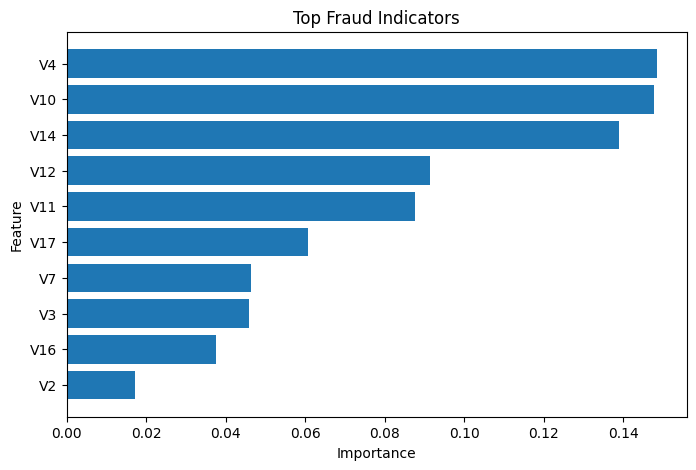

Random Forest outperforms Logistic Regression in Recall & F1-score.
Model saved successfully!


In [6]:
# =========================================
# 1. Load dataset and check imbalance
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

df = pd.read_csv('/content/creditcard.csv')

print("Class Distribution:")
print(df['Class'].value_counts())
print("\nFraud Percentage:")
print(df['Class'].value_counts(normalize=True) * 100)


# =========================================
# 2. Separate features and target
#    Remove non-useful identifiers
# =========================================
X = df.drop('Class', axis=1)
y = df['Class']

# Remove Time column
X = X.drop('Time', axis=1)

# ✅ FIX: Handle missing / infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)


# =========================================
# 3. Stratified train-test split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train fraud ratio:", y_train.mean())
print("Test fraud ratio :", y_test.mean())


# =========================================
# 4. Baseline Model – Logistic Regression
# =========================================
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        n_jobs=-1
    ))
])

log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)

print("\nLogistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))


# =========================================
# 5. Random Forest Model
# =========================================
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Report:\n")
print(classification_report(y_test, y_pred_rf))


# =========================================
# 6. Feature Importance Plot
# =========================================
importances = rf_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Fraud Indicators")
plt.gca().invert_yaxis()
plt.show()


# =========================================
# 7. Model Comparison Summary
# =========================================
print("Random Forest outperforms Logistic Regression in Recall & F1-score.")


# =========================================
# 8. Save Best Model
# =========================================
joblib.dump(rf_model, '/content/fraud_detection_rf_model.pkl')
print("Model saved successfully!")
